# Preprocess the data

In [53]:
import pandas as pd
import sqlite3
import numpy as np
import seaborn as sns
from scipy import stats

conn = sqlite3.connect('../slide/database/features.db')
#query = "SELECT channel, COUNT(well) as total_wells FROM LogsChannels GROUP BY channel ORDER BY total_wells DESC"
#df = pd.read_sql_query(query, conn)

In [21]:
query = "SELECT * FROM Features limit 1000000;"
df_features = pd.read_sql_query(query, conn)
numeric_columns = df_features.select_dtypes(include=[np.number]).columns
print(numeric_columns)
df_features

Index(['depth', 'GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI', 'MSFL',
       'DRHO', 'SFLU', 'top', 'bottom'],
      dtype='object')


,well,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom,rock
0,1BT2AM,270.0,63.279785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
1,1BT2AM,270.2,62.580566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
2,1BT2AM,270.4,64.454590,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
3,1BT2AM,270.6,65.624268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
4,1BT2AM,270.8,64.920898,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,302.5,ARGILITO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,3PIR7AL,1788.2,105.457748,-3.301666,74.474747,-999.25,4.499398,-999.25,-999.25,NaN,-999.25,4.040940,1782.0,1790.0,FOLHELHO
999996,3PIR7AL,1788.4,98.367188,-5.609985,69.902344,-999.25,4.501740,-999.25,-999.25,NaN,-999.25,5.707031,1782.0,1790.0,FOLHELHO
999997,3PIR7AL,1788.6,98.895508,-6.745575,69.823212,-999.25,4.713235,-999.25,-999.25,NaN,-999.25,7.059439,1782.0,1790.0,FOLHELHO
999998,3PIR7AL,1788.8,-999.250000,NaN,NaN,-999.25,NaN,-999.25,-999.25,NaN,-999.25,NaN,1782.0,1790.0,FOLHELHO


In [54]:
target_column = 'rock'
features_columns = [
        'depth',
        'top',
        'GR', 
        'SP', 
        'DT', 
        'CALI', 
        'ILD', 
        'RHOB', 
        'NPHI', 
        'MSFL',
        'DRHO', 
        'SFLU']
valid_rocks = [
    'FOLHELHO', 'ARENITO', 'SILTITO', 'CALCILUTITO', 'AREIA', 'CALCARENITO',
    'ARGILA', 'CALCARIO', 'CONGLOMERADO', 'ARGILITO', 'ANIDRITA', 'MARGA',
    'GRANITO', 'BASALTO', 'DOLOMITO'
]
"""
0        FOLHELHO  323879       42.41
1         ARENITO  278184       36.43
2         SILTITO   62312        8.16
3        ARGILITO   30446        3.99
4     CALCILUTITO   28771        3.77
5           AREIA    8235        1.08
6     CALCARENITO    6894        0.90
7          ARGILA    5886        0.77
8        CALCARIO    5091        0.67
9    CONGLOMERADO    4934        0.65
10        GRANITO    2797        0.37
11         HALITA    2484        0.33
12       ANIDRITA    1433        0.19
13       DOLOMITO    1083        0.14
14        BASALTO     776        0.10

0         ARENITO           63            100.00
1        FOLHELHO           63            100.00
2         SILTITO           60             95.24
3     CALCILUTITO           58             92.06
4           AREIA           34             53.97
5     CALCARENITO           32             50.79
6          ARGILA           29             46.03
7        CALCARIO           10             15.87
8    CONGLOMERADO            9             14.29
9        ARGILITO            8             12.70
10       ANIDRITA            8             12.70
11          MARGA            6              9.52
12        GRANITO            3              4.76
13        BASALTO            3              4.76
14       DOLOMITO            3              4.76
"""

'\n0        FOLHELHO  323879       42.41\n1         ARENITO  278184       36.43\n2         SILTITO   62312        8.16\n3        ARGILITO   30446        3.99\n4     CALCILUTITO   28771        3.77\n5           AREIA    8235        1.08\n6     CALCARENITO    6894        0.90\n7          ARGILA    5886        0.77\n8        CALCARIO    5091        0.67\n9    CONGLOMERADO    4934        0.65\n10        GRANITO    2797        0.37\n11         HALITA    2484        0.33\n12       ANIDRITA    1433        0.19\n13       DOLOMITO    1083        0.14\n14        BASALTO     776        0.10\n\n0         ARENITO           63            100.00\n1        FOLHELHO           63            100.00\n2         SILTITO           60             95.24\n3     CALCILUTITO           58             92.06\n4           AREIA           34             53.97\n5     CALCARENITO           32             50.79\n6          ARGILA           29             46.03\n7        CALCARIO           10             15.87\n8    CONGL

In [55]:


df_features_filtered = df_features.copy()

# Replace outliers with NaN
for col in features_columns:
    if col == "GR":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0) & (df_features_filtered[col] <= 200), df_features_filtered[col], np.nan)
    elif col == "SP":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= -100) & (df_features_filtered[col] <= 100), df_features_filtered[col], np.nan)
    elif col == "DT":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 40) & (df_features_filtered[col] <= 140), df_features_filtered[col], np.nan)
    elif col == "CALI":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 6) & (df_features_filtered[col] <= 16), df_features_filtered[col], np.nan)
    elif col == "ILD":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0.2) & (df_features_filtered[col] <= 2000), df_features_filtered[col], np.nan)
    elif col == "RHOB":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 1.95) & (df_features_filtered[col] <= 2.95), df_features_filtered[col], np.nan)
    elif col == "NPHI":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0) & (df_features_filtered[col] <= 0.45), df_features_filtered[col], np.nan)
    elif col == "MSFL":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0.2) & (df_features_filtered[col] <= 2000), df_features_filtered[col], np.nan)
    elif col == "DRHO":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= -0.1) & (df_features_filtered[col] <= 0.3), df_features_filtered[col], np.nan)
    elif col == "SFLU":
        df_features_filtered[col] = np.where((df_features_filtered[col] >= 0.2) & (df_features_filtered[col] <= 2000), df_features_filtered[col], np.nan)

# Filter rows based on valid rock types
df_features_filtered["rock"] = np.where(df_features_filtered['rock'].isin(valid_rocks), df_features_filtered["rock"], np.nan)
df_features_filtered.describe()


,depth,GR,SP,DT,CALI,ILD,RHOB,NPHI,MSFL,DRHO,SFLU,top,bottom
count,1000000.000000,663835.000000,559598.000000,274282.000000,405858.000000,484782.000000,359782.000000,694.000000,20697.000000,360807.000000,211845.000000,763708.000000,763708.000000
mean,2628.180389,68.657219,-29.796024,79.454698,10.570919,16.715606,2.450975,0.226148,6.624779,0.063885,58.187587,1424.764031,1438.812599
std,2499.114037,36.952135,22.406872,17.256518,1.900508,94.249221,0.147991,0.130741,34.920636,0.066575,262.547742,904.390223,907.683394
min,0.400000,0.000000,-99.997986,40.000000,6.077258,0.201597,1.950054,0.000000,0.225098,-0.099896,0.229858,3.000000,12.000000
25%,902.000000,44.714020,-45.144196,67.255821,8.935061,3.405273,2.355713,0.118920,0.784668,0.014000,4.698598,718.000000,729.000000
50%,1704.400000,69.781998,-28.670006,75.733414,9.943123,6.002999,2.461975,0.220288,1.957779,0.041000,7.894531,1305.000000,1313.000000
75%,3412.000000,92.366989,-13.561481,88.242188,12.142834,10.679688,2.564814,0.340750,6.351562,0.092350,15.377369,1997.000000,2007.000000
max,15427.657480,200.000000,64.203094,140.000000,16.000000,2000.000000,2.949828,0.449642,1956.429443,0.300000,2000.000000,4731.000000,5049.500000


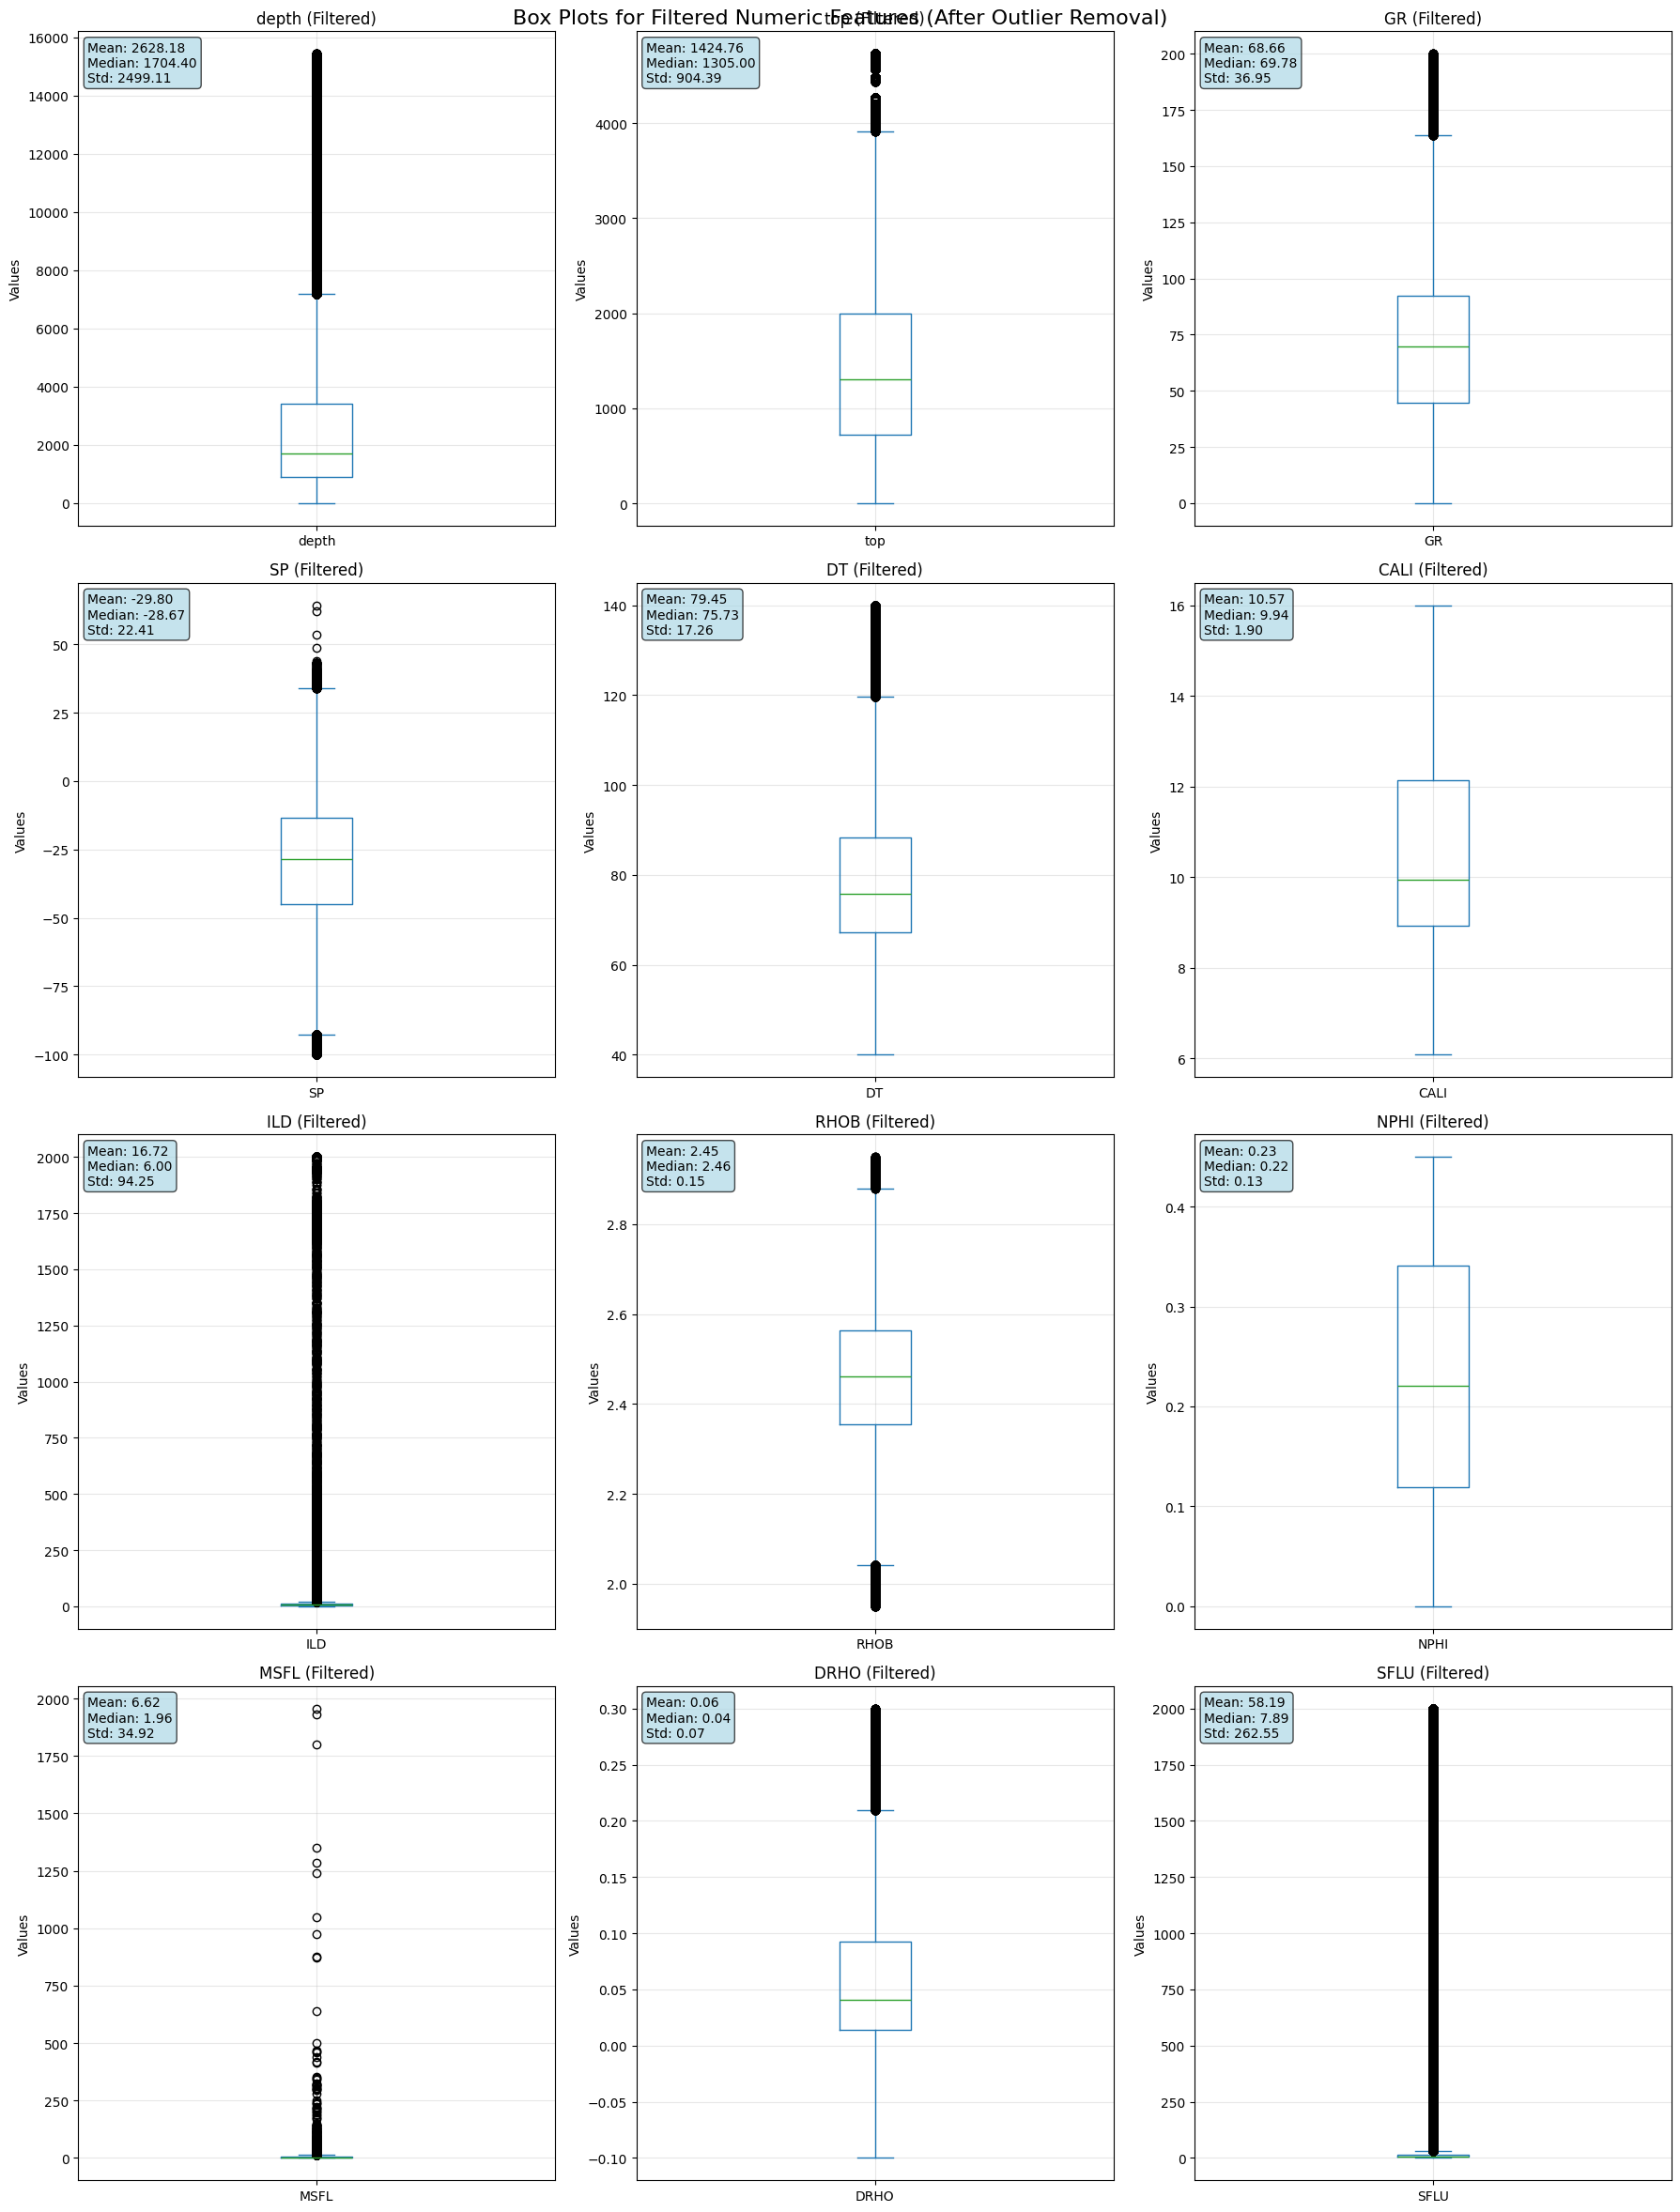

In [56]:
import matplotlib.pyplot as plt
# Create box plots for the filtered numeric columns (excluding depth, top, bottom)
filtered_numeric_columns_clean = features_columns.copy()#[col for col in features_columns if col.lower() not in [c.lower() for c in columns_to_exclude]]

n_cols_clean = len(filtered_numeric_columns_clean)
n_rows_clean = (n_cols_clean + 2) // 3  # 3 columns per row
fig, axes = plt.subplots(n_rows_clean, 3, figsize=(18, 6 * n_rows_clean))
fig.suptitle('Box Plots for Filtered Numeric Features (After Outlier Removal)', fontsize=16, y=0.98)

# Handle single subplot case
if n_cols_clean == 1:
    axes = [axes]
elif n_rows_clean == 1:
    axes = axes if n_cols_clean > 1 else [axes]
else:
    axes = axes.flatten()

# Create box plots for filtered data
for i, col in enumerate(filtered_numeric_columns_clean):
    ax = axes[i] if n_cols_clean > 1 else axes[0]
    
    # Create box plot
    df_features_filtered[col].plot(kind='box', ax=ax, title=f'{col} (Filtered)')
    ax.set_ylabel('Values')
    ax.grid(True, alpha=0.3)
    
    # Add statistics text
    stats_text = f'Mean: {df_features_filtered[col].mean():.2f}\nMedian: {df_features_filtered[col].median():.2f}\nStd: {df_features_filtered[col].std():.2f}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Hide unused subplots
for i in range(len(filtered_numeric_columns_clean), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

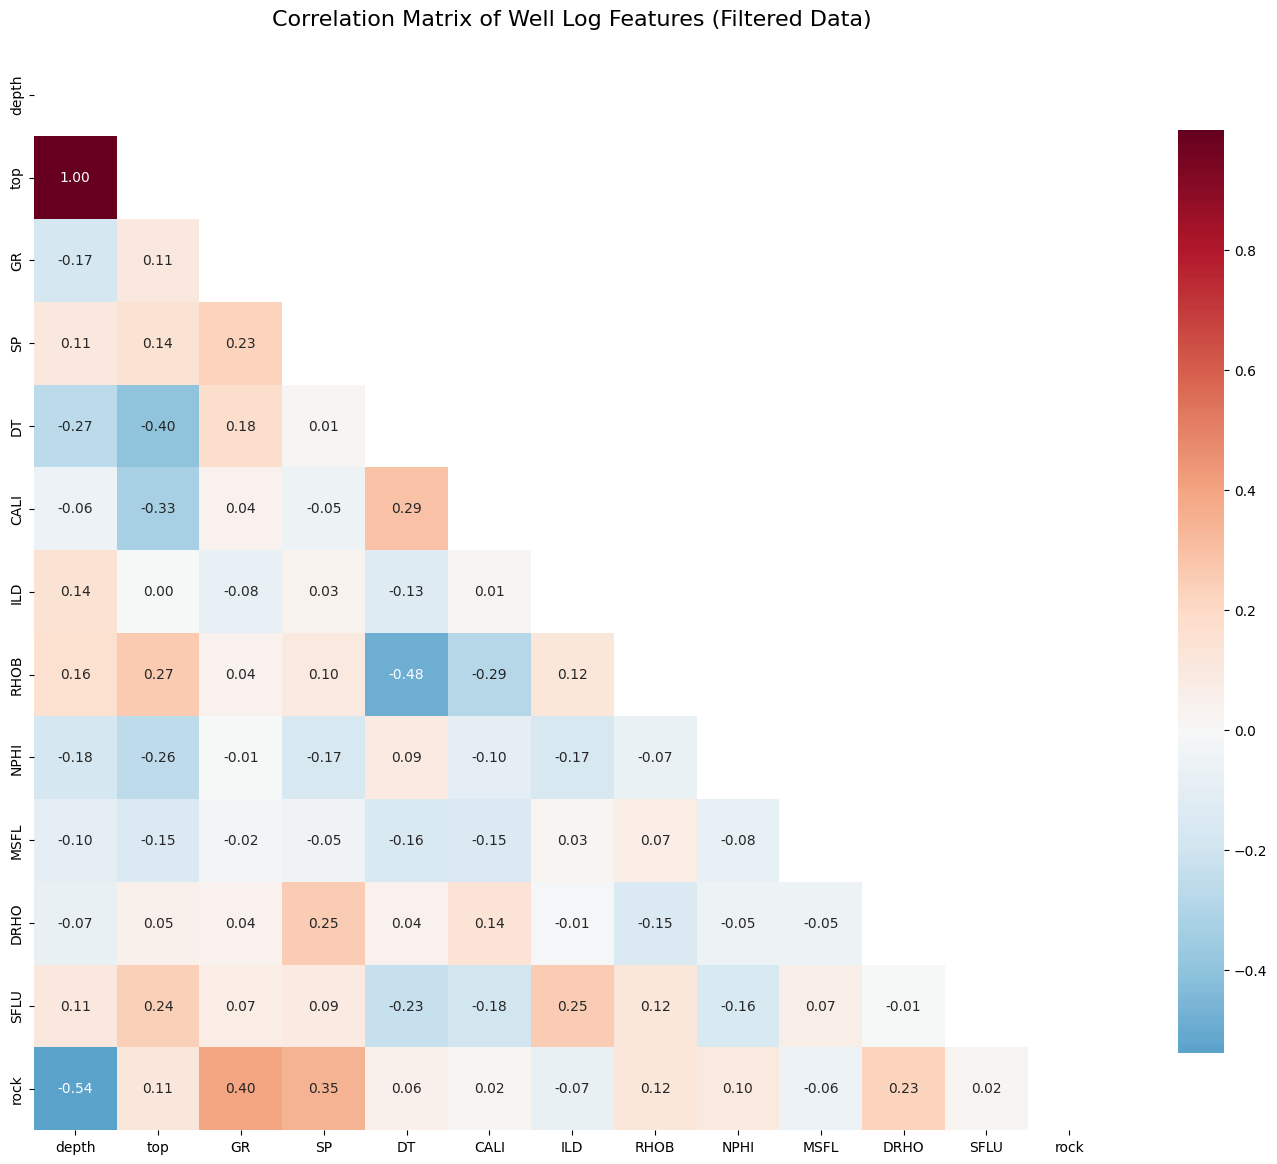


Strong Correlations (|r| > 0.7):

Normal Correlations (|r| > 0.4):

Weak Correlations (|r| > 0.1):
  Feature 1 Feature 2  Correlation
0     depth       top     0.999846

Normal Correlations (|r| > 0.4):
  Feature 1 Feature 2  Correlation
0     depth      rock    -0.538705
2        DT      RHOB    -0.483912
1       top        DT    -0.400910

Weak Correlations (|r| > 0.1):
   Feature 1 Feature 2  Correlation
17        GR      rock     0.398193
20        SP      rock     0.345724
9        top      CALI    -0.334062
21        DT      CALI     0.294146
25      CALI      RHOB    -0.285492
2      depth        DT    -0.267851
10       top      RHOB     0.266029
11       top      NPHI    -0.259710
31       ILD      SFLU     0.251779
19        SP      DRHO     0.248781
13       top      SFLU     0.239943
15        GR        SP     0.231564
36      DRHO      rock     0.228489
24        DT      SFLU    -0.226249
28      CALI      SFLU    -0.184845
5      depth      NPHI    -0.177389
16        GR

In [57]:
columns = filtered_numeric_columns_clean.copy()
columns.extend(["rock"])

df_features_cleaned = df_features_filtered.copy()
df_features_cleaned["rock"] = df_features_filtered["rock"].astype('category').cat.codes

# Create correlation matrix for numeric columns in the filtered dataset
correlation_matrix = df_features_cleaned[columns].corr()

# Create heatmap using matplotlib and seaborn
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Well Log Features (Filtered Data)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Print strong correlations (absolute value > 0.7)
print("\nStrong Correlations (|r| > 0.7):")
print("\nNormal Correlations (|r| > 0.4):")
print("\nWeak Correlations (|r| > 0.1):")
print("=" * 50)
strong_corr = []
normal_corr = []
weak_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            strong_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.4:
            normal_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })
        elif abs(corr_value) > 0.1:
            weak_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': corr_value
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
    print(strong_corr_df)
else:
    print("No strong correlations found (|r| > 0.7)")
    
if normal_corr:
    normal_corr_df = pd.DataFrame(normal_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nNormal Correlations (|r| > 0.4):")
    print(normal_corr_df)
else:
    print("No normal correlations found (|r| > 0.4)")
if weak_corr:
    weak_corr_df = pd.DataFrame(weak_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\nWeak Correlations (|r| > 0.1):")
    print(weak_corr_df)
else:
    print("No weak correlations found (|r| > 0.1)")

In [58]:
# Add boolean columns indicating null values for each numeric column
for col in numeric_columns:
    df_features_filtered[f'{col}_is_null'] = df_features_filtered[col].isnull().astype(int)

# Display the updated dataframe with null indicator columns
print("Added null indicator columns:")
print(df_features_filtered.columns.tolist())
print("\nDataframe shape:", df_features_filtered.shape)
print("\nSample of null indicator columns:")
null_indicator_cols = [col for col in df_features_filtered.columns if col.endswith('_is_null')]
print(df_features_filtered[null_indicator_cols].head())

Added null indicator columns:
['well', 'depth', 'GR', 'SP', 'DT', 'CALI', 'ILD', 'RHOB', 'NPHI', 'MSFL', 'DRHO', 'SFLU', 'top', 'bottom', 'rock', 'depth_is_null', 'GR_is_null', 'SP_is_null', 'DT_is_null', 'CALI_is_null', 'ILD_is_null', 'RHOB_is_null', 'NPHI_is_null', 'MSFL_is_null', 'DRHO_is_null', 'SFLU_is_null', 'top_is_null', 'bottom_is_null']

Dataframe shape: (1000000, 28)

Sample of null indicator columns:
   depth_is_null  GR_is_null  SP_is_null  DT_is_null  CALI_is_null  \
0              0           0           1           1             1   
1              0           0           1           1             1   
2              0           0           1           1             1   
3              0           0           1           1             1   
4              0           0           1           1             1   

   ILD_is_null  RHOB_is_null  NPHI_is_null  MSFL_is_null  DRHO_is_null  \
0            1             1             1             1             1   
1            1 

In [59]:
features_columns = [
        'depth',
        'depth_is_null',
        'top',
        'top_is_null',
        'GR', 
        'GR_is_null',
        'SP', 
        'SP_is_null',
        'DT', 
        'DT_is_null',
        'CALI', 
        'CALI_is_null',
        'ILD', 
        'ILD_is_null',
        'RHOB', 
        'RHOB_is_null',
        'NPHI', 
        'NPHI_is_null',
        'MSFL',
        'MSFL_is_null',
        'DRHO', 
        'DRHO_is_null',
        'SFLU',
        'SFLU_is_null']

Total unique wells: 63
Training wells: 50
Testing wells: 13

Training data shape: (711025, 24)
Testing data shape: (288975, 24)

Selected columns: ['depth', 'depth_is_null', 'top', 'top_is_null', 'GR', 'GR_is_null', 'SP', 'SP_is_null', 'DT', 'DT_is_null', 'CALI', 'CALI_is_null', 'ILD', 'ILD_is_null', 'RHOB', 'RHOB_is_null', 'NPHI', 'NPHI_is_null', 'MSFL', 'MSFL_is_null', 'DRHO', 'DRHO_is_null', 'SFLU', 'SFLU_is_null']


# Training

In [60]:
from sklearn.model_selection import train_test_split

# Get unique wells
unique_wells = df_features_filtered['well'].unique() if 'well' in df_features_filtered.columns else df_features['well'].unique()

# Split wells into train and test (80-20 split)
train_wells, test_wells = train_test_split(unique_wells, test_size=0.2, random_state=42)

# Create train and test datasets based on well splits
train_data = df_features_filtered[df_features_filtered['well'].isin(train_wells)][features_columns]
test_data = df_features_filtered[df_features_filtered['well'].isin(test_wells)][features_columns]

print(f"Total unique wells: {len(unique_wells)}")
print(f"Training wells: {len(train_wells)}")
print(f"Testing wells: {len(test_wells)}")
print(f"\nTraining data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")
print(f"\nSelected columns: {features_columns}")

Total unique wells: 63
Training wells: 50
Testing wells: 13

Training data shape: (711025, 24)
Testing data shape: (288975, 24)

Selected columns: ['depth', 'depth_is_null', 'top', 'top_is_null', 'GR', 'GR_is_null', 'SP', 'SP_is_null', 'DT', 'DT_is_null', 'CALI', 'CALI_is_null', 'ILD', 'ILD_is_null', 'RHOB', 'RHOB_is_null', 'NPHI', 'NPHI_is_null', 'MSFL', 'MSFL_is_null', 'DRHO', 'DRHO_is_null', 'SFLU', 'SFLU_is_null']


In [44]:
train_data

,depth,depth_is_null,top,top_is_null,GR,GR_is_null,SP,SP_is_null,DT,DT_is_null,...,RHOB,RHOB_is_null,NPHI,NPHI_is_null,MSFL,MSFL_is_null,DRHO,DRHO_is_null,SFLU,SFLU_is_null
12549,351.0,0,348.5,0,58.388992,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
12550,351.2,0,348.5,0,58.075989,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
12551,351.4,0,348.5,0,57.244995,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
12552,351.6,0,348.5,0,56.727997,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
12553,351.8,0,348.5,0,56.614990,0,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1788.2,0,1782.0,0,105.457748,0,-3.301666,0,74.474747,0,...,NaN,1,NaN,1,NaN,1,NaN,1,4.040940,0
999996,1788.4,0,1782.0,0,98.367188,0,-5.609985,0,69.902344,0,...,NaN,1,NaN,1,NaN,1,NaN,1,5.707031,0
999997,1788.6,0,1782.0,0,98.895508,0,-6.745575,0,69.823212,0,...,NaN,1,NaN,1,NaN,1,NaN,1,7.059439,0
999998,1788.8,0,1782.0,0,NaN,1,NaN,1,NaN,1,...,NaN,1,NaN,1,NaN,1,NaN,1,NaN,1


In [ ]:

# Get target column from training and test data
train_target = df_features_filtered[df_features_filtered['well'].isin(train_wells)][target_column]
test_target = df_features_filtered[df_features_filtered['well'].isin(test_wells)][target_column]

train_mask = train_target.notna()
test_mask = test_target.notna()

print(f"Training target shape: {train_target.shape}")
print(f"Testing target shape: {test_target.shape}")
print(f"\nTraining target distribution:")
print(train_target.value_counts())
print(f"\nTesting target distribution:")
print(test_target.value_counts())

Training target shape: (711025,)
Testing target shape: (288975,)

Training target distribution:
rock
FOLHELHO        246447
ARENITO         209867
SILTITO          48341
ARGILITO         21579
CALCILUTITO      21150
AREIA             6607
ARGILA            5496
CALCARENITO       5209
CONGLOMERADO      4918
CALCARIO          4848
GRANITO           2797
ANIDRITA          1143
DOLOMITO          1083
BASALTO            322
MARGA              167
Name: count, dtype: int64

Testing target distribution:
rock
FOLHELHO        77432
ARENITO         68317
SILTITO         13971
ARGILITO         8867
CALCILUTITO      7621
CALCARENITO      1685
AREIA            1628
BASALTO           454
ARGILA            390
ANIDRITA          290
CALCARIO          243
MARGA              56
CONGLOMERADO       16
Name: count, dtype: int64


In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

# Create masks for training and testing data
train_mask = train_target.notna()
test_mask = test_target.notna()

train_data = train_data[train_mask]
train_target = train_target[train_mask]
test_data = test_data[test_mask]
test_target = test_target[test_mask]

# Handle missing values by imputing with median for numeric features
imputer = SimpleImputer(strategy='median')
train_data_imputed = imputer.fit_transform(train_data)
test_data_imputed = imputer.transform(test_data)

# Train Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    verbose=1,  # This will show progress during training
    warm_start=True,  # Allow incremental training to track progress
    bootstrap=False  # Disable bootstrap to avoid breaking the sequential nature of well logs
)

# Train the model
print("Training Random Forest model...")
rf_model.fit(train_data_imputed, train_target)

# Make predictions
train_predictions = rf_model.predict(train_data_imputed)
test_predictions = rf_model.predict(test_data_imputed)

# Calculate accuracies
train_accuracy = accuracy_score(train_target, train_predictions)
test_accuracy = accuracy_score(test_target, test_predictions)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# Show classification report for test set
print("\nClassification Report (Test Set):")
print(classification_report(test_target, test_predictions))

# Feature importance
feature_importance = pd.DataFrame({
    'feature': features_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

Training Random Forest model...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  2.3min
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  5.2min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   10.4s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   19.9s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.6s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    5.3s finished



Training Accuracy: 0.9988
Testing Accuracy: 0.5340

Classification Report (Test Set):


c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\garcez\projects\venvs\slide\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

    ANIDRITA       0.01      0.00      0.00       290
       AREIA       0.30      0.36      0.33      1628
     ARENITO       0.56      0.59      0.58     68317
      ARGILA       0.10      0.21      0.13       390
    ARGILITO       0.34      0.16      0.22      8867
     BASALTO       0.71      0.20      0.31       454
 CALCARENITO       0.24      0.07      0.11      1685
    CALCARIO       0.00      0.00      0.00       243
 CALCILUTITO       0.12      0.02      0.04      7621
CONGLOMERADO       0.00      0.00      0.00        16
    DOLOMITO       0.00      0.00      0.00         0
    FOLHELHO       0.56      0.68      0.61     77432
       MARGA       0.00      0.00      0.00        56
     SILTITO       0.17      0.05      0.08     13971

    accuracy                           0.53    180970
   macro avg       0.22      0.17      0.17    180970
weighted avg       0.49      0.53      0.50    180970


Top 10 Most Important Fe